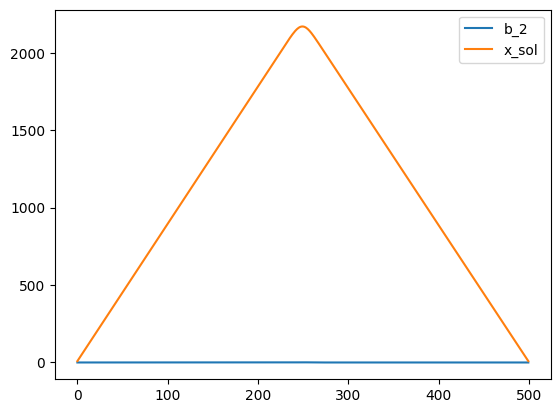

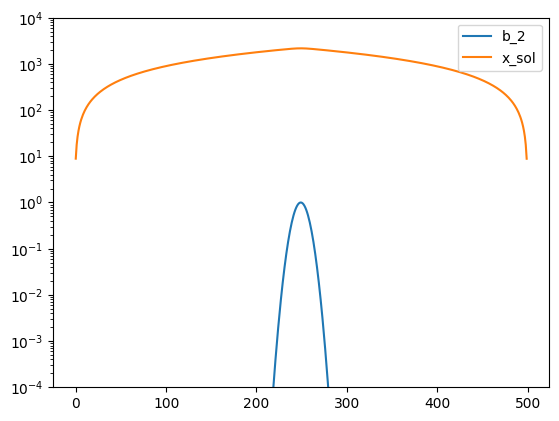

In [4]:
import numpy as np
import matplotlib.pyplot as plt

'''Ejercicio 12'''

# Algoritmo de cholesky con producto interior
def cholesky_int(A):
    n = A.shape[0]
    G = np.zeros((n,n))
    if A[0,0] <= 0:
        raise Exception('La matriz no es definida positiva') # Si se cumple la condicion
                                                             # salimos del algoritmo  (Hay una excepcion)
    G[0,:] = A[0,:]
    G[0,:] = G[0,:]/np.sqrt(G[0,0])

    for i in range(1, n):
        G[i,i:] = A[i, i:]- G[0:i,i].T@G[0:i,i:]
        if G[i,i] < 0:
            raise Exception('La matriz no es definida positiva') # Si se cumple la condicion
                                                                 # Tenemos una excepcion
        G[i,i:] = G[i,i:]/np.sqrt(G[i,i])
    return G

# TEST
# B = np.array([[4., 2, 6,], [2, 2, 5], [6, 5, 29]])
# G_sol = cholesky_int(B)
# print(f'B={B}')
# print(f'G = {G_sol}')
# print(f'G.T@G ={G_sol.T@G_sol}')

'''Ejercicio 13'''

n = 500
# np.diag nos devuelve una matriz de ceros salvo una diagonal.
A = -np.diag(np.ones(n-1), 1)-np.diag(np.ones(n-1), -1)+2*np.eye(n)

G = cholesky_int(A)

# print(G.T@G)

'''Ejericio 14'''

def sol_trinffil (A, b):
    x = b.copy()
    n = len(b)
    for idx, elem in enumerate(b):
        if elem !=0:
            j = idx
            break
    for i in range(j, n):
        x[i] = (b[i] - A[i, :i] @ x[:i])/A[i,i]
    return x

def sol_trsupfil (A, b):
    n = len(b)
    x = b.copy()
    for idx in reversed(range(n)):
        if b[idx] !=0:
            j = idx
            break
    for i in reversed(range(j+1)):
        x[i] = (b[i] - A[i, i+1:] @ x[i+1:])/A[i,i]
    return x

def sol_defpos(A,b):
    G = cholesky_int(A)
    y = sol_trinffil(G.T, b)
    x = sol_trsupfil(G, y)
    return x

'''Ejercicio 15'''

b_2 = np.zeros(n)
c = n/2
for j in range(n):
    b_2[j] = np.exp(-((j+1)-c)**2/100)

x_sol = sol_defpos(A, b_2)

# Graficamos
plt.plot(b_2, label = 'b_2')
plt.plot(x_sol, label = 'x_sol')
plt.legend()
plt.show()

# Graficamos en una escala logaritmica
plt.semilogy(b_2, label = 'b_2')
plt.semilogy(x_sol, label = 'x_sol')
plt.ylim([1e-4, 1e4])
plt.legend()
plt.show()

# IMPORTANTE
# La idea de graficar la solucion y el vector b_2 es observar que la solucion es 'rara' y el vector b
# es practicamente nulo.
# Esto se de a que la matriz del sistema es mal condicionada.